## 0. Описание лабораторной работы

Вам предоставлен набор данных, который содержит информацию о клиентах банка:

- **client_id** - ID клиента (неотрицательное целое число)
- **Age** - возраст (вещественный)
- **Income** - месячный доход (вещественный)
- **BalanceToCreditLimit** - отношение баланса на кредитной карте к лимиту по кредиту (вещественный)
- **DIR** - Debt-to-income Ratio (вещественный)
- **NumLoans** - число заемов и кредитных линий
- **NumRealEstateLoans** - число ипотек и заемов, связанных с недвижимостью (натуральное число)
- **NumDependents** - число членов семьи, которых содержит клиент, исключая самого клиента (натуральное число)
- **Num30-59Delinquencies** - число просрочек выплат по кредиту от 30 до 59 дней (натуральное число)
- **Num60-89Delinquencies** - число просрочек выплат по кредиту от 60 до 89 дней (натуральное число)
- **Delinquent90** - Таргет, были ли просрочки выплат по кредиту более 90 дней (бинарный)

**Задание:**

**1. Анализ и предобработка**
- Проанализировать данные (EDA)
- Предобработать данные
- Скалировать/нормализовать данные
- Подготовить данные для обучения моделей

**2. Дерево решений**
- Обучить дерево решений, визуализировать решающее дерево
- Рассмотреть, как изменение глубины дерева влияет на качество модели. Обучите решающее дерево с различной глубиной (от 1 до 11), оцените его точность и определите, когда начинается переобучение и какая глубина дерева является оптимальной
- Подберите оптимальные параметры дерева с помощью GridSearchCV

**3. Ансамблевые методы**
- Выберите любую классическую модель (не ансамблевую) и обучите ансамбль с помощью бэггинга (BaggingClassifier). Подберите оптимальные параметры как бэггинга, так и модели с помощью GridSearchCV
- Выберите любые классические модели (не ансамблевые) и обучите ансамбль с помощью стекинга (StackingClassifier). Подберите оптимальные параметры как стекинга, так и модели с помощью GridSearchCV
- Обучите случайный лес (RandomForestClassifier), настройте гиперпараметры случайного леса с помощью GridSearchCV
- Инициализируйте параметры и обучите классификатор XGBoost (обратите внимание, что XGBoost работает только с числовыми признаками). Вычислите F test (не F score!) для оценки важности признаков в XGBoost

In [ ]:
import warnings
warnings.filterwarnings('ignore')
import plotly.io as pio
import plotly.express as px
pio.templates.default = 'plotly_white'
from plotly.subplots import make_subplots
import plotly.graph_objects as go

import polars as pl
import numpy as np
import random
import sklearn
import os

seed = 42
random.seed(seed)
np.random.seed(seed)
sklearn.random.seed(seed)
os.environ['PYTHONHASHSEED'] = str(seed)

## 1. Анализ и предобработка


In [ ]:
data_url = 'https://github.com/Lopa10ko/itmo-ml-2025/raw/main/lab-4/credit_scoring.csv'
df_pl = pl.read_csv(data_url)

display(df_pl.head())
print(f'Размер датасета: {df_pl.shape}\n')

client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
i64,f64,f64,i64,i64,f64,i64,i64,f64,f64,i64
0,0.496289,49.1,13,0,0.0,2,0,5298.360639,0.387028,0
1,0.433567,48.0,9,2,2.0,1,0,6008.056256,0.234679,0
2,2206.731199,55.5,21,1,null,1,0,null,0.348227,0
3,886.132793,55.3,3,0,0.0,0,0,null,0.97193,0
4,0.0,52.3,1,0,0.0,0,0,2504.613105,1.00435,0


Размер датасета: (75000, 11)



Датасет содержит 75,000 записей о клиентах банка, что является достаточно репрезентативной выборкой для построения моделей. Не могу дождаться момента, когда почищу все пропуски и удалю половину этих записей (шутка).

In [ ]:
print(f'Описательная статистика:')
df_pl.describe()


Описательная статистика:


statistic,client_id,DIR,Age,NumLoans,NumRealEstateLoans,NumDependents,Num30-59Delinquencies,Num60-89Delinquencies,Income,BalanceToCreditLimit,Delinquent90
str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""count""",75000.0,75000.0,75000.0,75000.0,75000.0,73084.0,75000.0,75000.0,60153.0,75000.0,75000.0
"""null_count""",0.0,0.0,0.0,0.0,0.0,1916.0,0.0,0.0,14847.0,0.0,0.0
"""mean""",37499.5,353.260293,52.595605,8.44976,1.016693,0.755966,0.42832,0.248,6740.059287,6.276196,0.06684
"""std""",21650.779432,2117.237432,14.869729,5.15644,1.124019,1.108119,4.276439,4.239486,14228.75488,267.743321,0.249746
"""min""",0.0,0.0,21.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""25%""",18750.0,0.176027,41.3,5.0,0.0,0.0,0.0,0.0,3421.353782,0.029703,0.0
"""50%""",37500.0,0.366849,52.2,8.0,1.0,0.0,0.0,0.0,5424.552473,0.15372,0.0
"""75%""",56249.0,0.862626,63.1,11.0,2.0,1.0,0.0,0.0,8291.517816,0.560637,0.0
"""max""",74999.0,332600.27282,109.8,56.0,32.0,20.0,98.0,98.0,1.8056e6,50873.874533,1.0


На основе увиденного можно сделать следующие выводы о датасете:

1. Наблюдается несколько проблемных фичей с пропусками:
   - `NumDependents` - 1,916 пропусков (2.5% данных)
   - `Income` - 14,847 пропусков (19.8% данных) - наиболее критичная проблема

2. **Ключевые характеристики клиентов**:
   - Средний возраст клиентов - 52.6 года (от 21 до 109 лет)
   - Средний месячный доход - 6,740 единиц, но распределение сильно скошено (std=14,228)
   - Медианное значение дохода - 5,424 единицы
   - Большинство клиентов имеют 0-1 иждивенцев (медиана = 0)

3. **Кредитное поведение**:
   - В среднем у клиентов 8.4 активных кредита
   - Большинство имеют 1 ипотеку или заем на недвижимость
   - Просрочки 30-59 дней встречаются у 42.8% клиентов
   - Просрочки 60-89 дней - у 24.8% клиентов
   - Целевая переменная `Delinquent90` показывает, что 6.7% клиентов имели серьезные просрочки (>90 дней)

4. **Потенциальные проблемы данных**:
   - Значение `DIR` (Debt-to-income Ratio) имеет экстремальный максимум 332,600, что требует проверки на выбросы
   - `BalanceToCreditLimit` также показывает аномально высокие значения (максимум 50,873)
   - Возраст 109 лет требует верификации
   - Максимальное количество просрочек (98) выглядит подозрительно

### 1.1 Общий анализ данных

In [ ]:
print('Схема данных Polars:')
print(*[(k, v) for k, v in df_pl.schema.items()], sep='\n')

Схема данных Polars:
('client_id', Int64)
('DIR', Float64)
('Age', Float64)
('NumLoans', Int64)
('NumRealEstateLoans', Int64)
('NumDependents', Float64)
('Num30-59Delinquencies', Int64)
('Num60-89Delinquencies', Int64)
('Income', Float64)
('BalanceToCreditLimit', Float64)
('Delinquent90', Int64)


 Показываем уникальные значения для (потенциально) категориальных признаков

In [ ]:
from prettytable import PrettyTable

threshold_nunique = 30
uniques_tb = PrettyTable()
uniques_tb.field_names = ['feature', 'n_unique', f'Values (if quantity less than {threshold_nunique})']
category_like_columns = []

for col in df_pl.columns:
    unique_count = df_pl[col].n_unique()
    if unique_count < threshold_nunique:
        category_like_columns.append(col)
        unique_values = df_pl[col].drop_nulls().unique().sort().to_list()
        values_str = ', '.join(map(str, unique_values))
    else:
        values_str = '-'

    uniques_tb.add_row([col, unique_count, values_str])

print(uniques_tb)

+-----------------------+----------+--------------------------------------------------------------------------------------+
|        feature        | n_unique |                          Values (if quantity less than 30)                           |
+-----------------------+----------+--------------------------------------------------------------------------------------+
|       client_id       |  75000   |                                          -                                           |
|          DIR          |  70376   |                                          -                                           |
|          Age          |   527    |                                          -                                           |
|        NumLoans       |    55    |                                          -                                           |
|   NumRealEstateLoans  |    24    | 0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 19, 20, 23, 25, 26, 32 |
|     Nu

Теперь выведем таблицы для каждого (потенциально) категориального признака и посмотрим распределение сэмплов по каждому из значений. Дальше при обработке я буду руководствоваться похожими агрегатами, чтобы удалять из сэмплов нерепрезентативные классы.

In [ ]:
from prettytable import PrettyTable

def print_unique_values_table(df, category):
    print(f'\n{"="*50}')
    print(f'Unique values in {category}:')
    print(f'\n{"="*50}')
    category_counts = df.group_by(category).agg(pl.count().alias('count')).sort('count', descending=True)
    table = PrettyTable()
    table.field_names = [category, 'count', 'percent (%)']

    total_count = category_counts['count'].sum()
    for row in category_counts.iter_rows(named=True):
        value = row[category]
        count = row['count']
        percentage = (count / total_count) * 100
        table.add_row([value, count, f'{percentage:.1f}%'])

    print(table)

for category in category_like_columns:
    print_unique_values_table(df_pl, category)


Unique values in NumRealEstateLoans:

+--------------------+-------+-------------+
| NumRealEstateLoans | count | percent (%) |
+--------------------+-------+-------------+
|         0          | 28046 |    37.4%    |
|         1          | 26332 |    35.1%    |
|         2          | 15707 |    20.9%    |
|         3          |  3106 |     4.1%    |
|         4          |  1065 |     1.4%    |
|         5          |  318  |     0.4%    |
|         6          |  182  |     0.2%    |
|         7          |   90  |     0.1%    |
|         8          |   51  |     0.1%    |
|         9          |   38  |     0.1%    |
|         10         |   19  |     0.0%    |
|         11         |   11  |     0.0%    |
|         12         |   10  |     0.0%    |
|         13         |   6   |     0.0%    |
|         15         |   5   |     0.0%    |
|         14         |   3   |     0.0%    |
|         17         |   2   |     0.0%    |
|         25         |   2   |     0.0%    |
|         20    

Из этих частотных таблиц видно, что:

1. Почти во всех признаках наблюдается логнормальное дискретное распределение классов.
5. `Delinquent90` - таргет несбалансированный.

In [ ]:
df_cleared = df_pl.clone()

In [ ]:
print('Before', end='')
print_unique_values_table(df_cleared, 'NumRealEstateLoans')
df_cleared = df_cleared.filter(pl.col('NumRealEstateLoans') < 4)
print('\nAfter', end='')
print_unique_values_table(df_cleared, 'NumRealEstateLoans')
df_cleared.shape

Before
Unique values in NumRealEstateLoans:

+--------------------+-------+-------------+
| NumRealEstateLoans | count | percent (%) |
+--------------------+-------+-------------+
|         0          | 28046 |    37.4%    |
|         1          | 26332 |    35.1%    |
|         2          | 15707 |    20.9%    |
|         3          |  3106 |     4.1%    |
|         4          |  1065 |     1.4%    |
|         5          |  318  |     0.4%    |
|         6          |  182  |     0.2%    |
|         7          |   90  |     0.1%    |
|         8          |   51  |     0.1%    |
|         9          |   38  |     0.1%    |
|         10         |   19  |     0.0%    |
|         11         |   11  |     0.0%    |
|         12         |   10  |     0.0%    |
|         13         |   6   |     0.0%    |
|         15         |   5   |     0.0%    |
|         14         |   3   |     0.0%    |
|         20         |   2   |     0.0%    |
|         25         |   2   |     0.0%    |
|         

(73191, 11)

In [ ]:
print('Before', end='')
print_unique_values_table(df_cleared, 'NumDependents')
df_cleared = df_cleared.filter(pl.col('NumDependents') <= 3)
print('\nAfter', end='')
print_unique_values_table(df_cleared, 'NumDependents')
df_cleared.shape

Before
Unique values in NumDependents:

+---------------+-------+-------------+
| NumDependents | count | percent (%) |
+---------------+-------+-------------+
|      0.0      | 42435 |    58.0%    |
|      1.0      | 12937 |    17.7%    |
|      2.0      |  9609 |    13.1%    |
|      3.0      |  4506 |     6.2%    |
|      None     |  1896 |     2.6%    |
|      4.0      |  1365 |     1.9%    |
|      5.0      |  336  |     0.5%    |
|      6.0      |   73  |     0.1%    |
|      7.0      |   17  |     0.0%    |
|      8.0      |   11  |     0.0%    |
|      10.0     |   2   |     0.0%    |
|      9.0      |   2   |     0.0%    |
|      20.0     |   1   |     0.0%    |
|      13.0     |   1   |     0.0%    |
+---------------+-------+-------------+

After
Unique values in NumDependents:

+---------------+-------+-------------+
| NumDependents | count | percent (%) |
+---------------+-------+-------------+
|      0.0      | 42435 |    61.1%    |
|      1.0      | 12937 |    18.6%    |


(69487, 11)

Все остальные фичи (`Num30-59Delinquencies` и `Num60-89Delinquencies`) бинаризуем.

In [ ]:
delinquency_columns = ["Num30-59Delinquencies", "Num60-89Delinquencies"]
for col in delinquency_columns:
    df_cleared = df_cleared.with_columns((pl.col(col) != 0).cast(pl.Int8).alias(col))

In [ ]:
for category in category_like_columns:
    print_unique_values_table(df_cleared, category)


Unique values in NumRealEstateLoans:

+--------------------+-------+-------------+
| NumRealEstateLoans | count | percent (%) |
+--------------------+-------+-------------+
|         0          | 26427 |    38.0%    |
|         1          | 25075 |    36.1%    |
|         2          | 15028 |    21.6%    |
|         3          |  2957 |     4.3%    |
+--------------------+-------+-------------+

Unique values in NumDependents:

+---------------+-------+-------------+
| NumDependents | count | percent (%) |
+---------------+-------+-------------+
|      0.0      | 42435 |    61.1%    |
|      1.0      | 12937 |    18.6%    |
|      2.0      |  9609 |    13.8%    |
|      3.0      |  4506 |     6.5%    |
+---------------+-------+-------------+

Unique values in Num30-59Delinquencies:

+-----------------------+-------+-------------+
| Num30-59Delinquencies | count | percent (%) |
+-----------------------+-------+-------------+
|           0           | 58532 |    84.2%    |
|           1

То есть новое описание фичей `Num30-59Delinquencies` и `Num60-89Delinquencies`:

1. `Num30-59Delinquencies` - (бинарный) были ли просрочки выплат по кредиту от 30 до 59 дней
2. `Num60-89Delinquencies` - (бинарный) были ли просрочки выплат по кредиту от 60 до 89 дней

### 1.2 Обработка пропущенных значений


Вновь посмотрим, сколько пропущенных значений в каждом столбце:

In [ ]:
def analyze_missing_values_by_column(df):
    total_rows = df.height

    missing_analysis = df.select([
        pl.col(col).null_count().alias(f'{col}_missing') for col in df.columns
    ]).transpose(include_header=True, header_name='column', column_names=['missing_count'])

    missing_df = missing_analysis.with_columns([
        (pl.col('missing_count') / total_rows * 100).alias('missing_percent')
    ]).sort('missing_percent', descending=True)

    missing_with_nulls = missing_df.filter(pl.col('missing_count') > 0)
    if len(missing_with_nulls) == 0:
        return "No more missing values!"

    print(missing_with_nulls)

    missing_data = {
        'column': missing_with_nulls['column'].to_list(),
        'missing_percent': missing_with_nulls['missing_percent'].to_list()
    }
    fig = px.bar(
        missing_data,
        x='column',
        y='missing_percent',
        title='Missing values percent by column',
        labels={'missing_percent': 'Missing values percent', 'column': 'columns'},
        color='missing_percent',
        color_continuous_scale='Reds'
    )
    fig.update_layout(
        xaxis_tickangle=-45,
        height=500,
        showlegend=False
    )
    fig.show()

analyze_missing_values_by_column(df_cleared)

shape: (1, 3)
┌────────────────┬───────────────┬─────────────────┐
│ column         ┆ missing_count ┆ missing_percent │
│ ---            ┆ ---           ┆ ---             │
│ str            ┆ u32           ┆ f64             │
╞════════════════╪═══════════════╪═════════════════╡
│ Income_missing ┆ 12547         ┆ 18.056615       │
└────────────────┴───────────────┴─────────────────┘


Стратегия заполнения пропущенных значений:
KNN на основе вещественных признаков

In [ ]:
from sklearn.impute import KNNImputer

imputer = KNNImputer(n_neighbors=5)
numeric_columns = ['Age', 'Income', 'BalanceToCreditLimit', 'DIR', 'NumLoans']

df_numeric = df_cleared.select(numeric_columns)
imputed_data = imputer.fit_transform(df_numeric.to_numpy())

df_cleared = df_cleared.with_columns([
    pl.Series(numeric_columns[i], imputed_data[:, i])
    for i in range(len(numeric_columns))
])

Ну вот и все, кажется, от пропусков избавились.

In [ ]:
analyze_missing_values_by_column(df_cleared)

'No more missing values!'

### 1.3 Обработка аномальных значений и выбросов


In [ ]:
numeric_features = [col for col in df_cleared.columns
                    if col not in category_like_columns and col != 'client_id']
print('Numeric features:', numeric_features)

Numeric features: ['DIR', 'Age', 'NumLoans', 'Income', 'BalanceToCreditLimit']


Взглянем также на распределение каждого признака и соответсвующее ему нормальное.

Применим для каждого вещественного признака квантильное преобразование, чтобы гарантированно получить нормальные распределения.

In [ ]:
from sklearn.preprocessing import QuantileTransformer

def quantile_transform_visualize(df, columns):
    df_transformed = df.clone()

    fig = make_subplots(rows=len(columns), cols=2,
        subplot_titles=[f'{col} ({suffix})' for col in columns
                       for suffix in ['before', 'after']],
        vertical_spacing=0.05)
    for i, col in enumerate(columns):
        original_data = df[col].to_numpy()
        transformer = QuantileTransformer(output_distribution='normal', random_state=42)
        transformed_data = transformer.fit_transform(original_data.reshape(-1, 1)).flatten()

        df_transformed = df_transformed.with_columns(
            pl.Series(col, transformed_data)
        )

        fig.add_trace(go.Histogram(x=original_data, showlegend=False), row=i+1, col=1)
        fig.add_trace(go.Histogram(x=transformed_data, showlegend=False), row=i+1, col=2)

    fig.update_layout(height=300 * len(columns), title_text="Quantile Transformation")
    fig.show()

    return df_transformed

df_processed = quantile_transform_visualize(df_cleared, numeric_features)

In [ ]:
!pip install pyod --quiet

In [ ]:
from pyod.models.ecod import ECOD
import polars as pl
import numpy as np

def ecod_clean_dataset(df, contamination=0.1):
    original_indices = np.arange(len(df))
    numeric_cols = df.select(pl.col(pl.NUMERIC_DTYPES)).columns
    X = df[numeric_cols].to_numpy()

    detector = ECOD(contamination=contamination)
    outlier_labels = detector.fit_predict(X)
    outlier_scores = detector.decision_scores_
    n_outliers = outlier_labels.sum()
    cleaned_df = df.filter(pl.Series(outlier_labels == 0))

    return cleaned_df, outlier_scores, outlier_labels

df_processed, scores, labels = ecod_clean_dataset(df_processed)

In [ ]:
df_cleared.shape

(69487, 11)

In [ ]:
print(f'Raw data shape: {df_pl.shape}')
print(f'Cleared data shape: {df_processed.shape}')

Raw data shape: (75000, 11)
Cleared data shape: (62538, 11)


Отбор нужных нам колонок:

In [ ]:
df_processed.columns

['client_id',
 'DIR',
 'Age',
 'NumLoans',
 'NumRealEstateLoans',
 'NumDependents',
 'Num30-59Delinquencies',
 'Num60-89Delinquencies',
 'Income',
 'BalanceToCreditLimit',
 'Delinquent90']

In [ ]:
target_column = 'Delinquent90'
category_like_columns.remove(target_column)
categoric_features_in_use = category_like_columns
non_numeric_features = [target_column] + category_like_columns + ['client_id']
numeric_features_in_use = [col for col in df_processed.columns if col not in non_numeric_features]

In [ ]:
print('Numeric features:', numeric_features_in_use)
print('Categoric features:', categoric_features_in_use)
print('Target feature:', target_column)
FEATURES_IN_USE = numeric_features_in_use + categoric_features_in_use

Numeric features: ['DIR', 'Age', 'NumLoans', 'Income', 'BalanceToCreditLimit']
Categoric features: ['NumRealEstateLoans', 'NumDependents', 'Num30-59Delinquencies', 'Num60-89Delinquencies']
Target feature: Delinquent90


### 1.4. Кодирование и скалирование

Анализ распределений до этого момента был достаточно сумбурным (да и сейчас ничего не поменяется), но я специально вел отдельно учет категориальных признаков (чтобы применить к ним one-hot encoding), отдельно логарифмированных признаков (чтобы применить к ним скейлинг).

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

df_normed = df_processed.select(FEATURES_IN_USE).to_pandas()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features_in_use),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categoric_features_in_use)
    ]
)

transformed_data = preprocessor.fit_transform(df_normed)
categorical_names = preprocessor.named_transformers_['cat'].get_feature_names_out(categoric_features_in_use)
feature_names = np.concatenate([numeric_features_in_use, categorical_names])

df_normed = pd.DataFrame(transformed_data, columns=feature_names)
df_normed

,DIR,Age,NumLoans,Income,BalanceToCreditLimit,NumRealEstateLoans_1,NumRealEstateLoans_2,NumRealEstateLoans_3,NumDependents_1.0,NumDependents_2.0,NumDependents_3.0,Num30-59Delinquencies_1,Num60-89Delinquencies_1
0,-0.391836,0.678637,0.480314,0.588659,-0.539048,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.217643,-0.143728,0.281361,0.811042,0.590322,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.799973,0.473391,0.480314,-0.447449,-0.123927,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,-0.343797,0.001496,0.063428,0.516622,0.036727,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,0.248662,-0.936406,0.674101,-0.105064,0.112741,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
62533,0.012931,-0.875282,0.281361,-0.242006,0.322080,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0
62534,-0.093485,-1.006753,0.674101,0.513291,0.308307,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62535,0.445966,-0.643295,0.480314,-0.280879,0.266835,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
62536,-0.288790,0.492787,0.063428,0.443809,0.523899,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0


## 2. Дерево решений

**Цель:**
разработать модель бинарной классификации, которая с достаточной точностью оценивает булево значение `Delinquent90` по набору признаков, описывающих профиль клиента.

In [ ]:
df_pd = df_normed.copy()
X, y = df_pd, df_processed[target_column].to_pandas()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.1, random_state=seed)

print(f'Train subset: {X_train.shape[0]} ({X_train.shape[0]/X.shape[0]:.2%})')
print(f'Test subset: {X_test.shape[0]} ({X_test.shape[0]/X.shape[0]:.2%})')

Train subset: 56284 (90.00%)
Test subset: 6254 (10.00%)


Буду пытаться все держать в чистой функциональной реализации.

Например, вот аккуратненький метод для подсчета ключевых метрик в задаче бинарной классификации.

In [ ]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, classification_report)

def evaluate_model(model, X, y):
    y_pred = model.predict(X)
    y_pred_proba = model.predict_proba(X)[:, 1]

    accuracy = accuracy_score(y, y_pred)
    precision = precision_score(y, y_pred)
    recall = recall_score(y, y_pred)
    f1 = f1_score(y, y_pred)
    auc_roc = roc_auc_score(y, y_pred_proba)

    class_report = classification_report(y, y_pred, output_dict=True)

    return {
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'auc_roc': auc_roc,
        'classification_report': class_report
    }

Дерево решений будет обучаться в k фолдах со стратификацией.

Не забудем про сильный дисбаланс классов в таргете - будем назначать весовые коэффиценты

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.utils.class_weight import compute_class_weight

def train_decision_tree_with_cv(X_train, y_train, max_depth=3):
    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=seed)
    cv_scores = []
    best_score = -1
    best_tree = None
    class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
    class_weight_dict = dict(zip(np.unique(y_train), class_weights))


    for train_idx, val_idx in skf.split(X_train, y_train):
        X_fold_train, X_fold_val = X_train.iloc[train_idx], X_train.iloc[val_idx]
        y_fold_train, y_fold_val = y_train.iloc[train_idx], y_train.iloc[val_idx]

        dt = DecisionTreeClassifier(class_weight=class_weight_dict,
                                   max_depth=max_depth,
                                   random_state=seed)
        dt.fit(X_fold_train, y_fold_train)
        fold_score = dt.score(X_fold_val, y_fold_val)
        cv_scores.append(fold_score)

        if fold_score > best_score:
            best_score = fold_score
            best_tree = dt

    return {'cv_scores': cv_scores, 'best_tree': best_tree}

In [ ]:
results = {}

1. Training Decision Tree with StratifiedKFold...


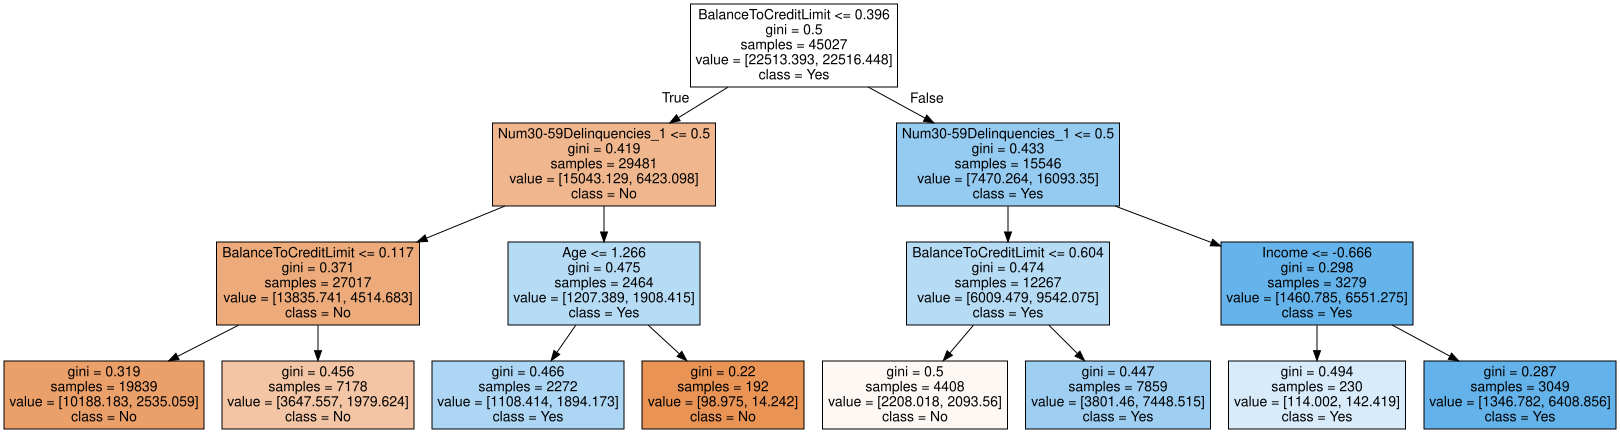

In [ ]:
from sklearn.tree import export_graphviz
import graphviz
from IPython.display import Image, display

if 'best_tree' not in results.keys():
    print("1. Training Decision Tree with StratifiedKFold...")
    cv_results = train_decision_tree_with_cv(X_train, y_train)
    results.update(cv_results)

dt_final = results['best_tree']
dot_data = export_graphviz(dt_final, feature_names=X.columns,
                           class_names=['No', 'Yes'], filled=True)
tree_graph = graphviz.Source(dot_data)
tree_graph

Будем назначать глубину дерева от 1 до 11 и сравнивать метрики точности на тренировочной и тестовой подвыборках.

In [ ]:
def analyze_tree_depth(X_train, y_train, X_test, y_test, max_depth=11):
    depth_results = []

    for depth in range(1, max_depth + 1):
        dt_depth = DecisionTreeClassifier(class_weight='balanced',
                                         max_depth=depth,
                                         random_state=seed)
        dt_depth.fit(X_train, y_train)

        train_metrics = evaluate_model(dt_depth, X_train, y_train)
        test_metrics = evaluate_model(dt_depth, X_test, y_test)

        depth_results.append({'depth': depth,
                              'train_accuracy': train_metrics['accuracy'],
                              'test_accuracy': test_metrics['accuracy'],
                              'train_f1': train_metrics['f1_score'],
                              'test_f1': test_metrics['f1_score']})

    return depth_results

def plot_depth_analysis(depth_results):
    depth_df = pd.DataFrame(depth_results)
    fig = make_subplots(rows=1, cols=2, subplot_titles=('Accuracy vs Depth',
                                                       'F1 Score vs Depth'))
    fig.add_trace(go.Scatter(x=depth_df['depth'], y=depth_df['train_accuracy'],
                            name='Train Accuracy', line=dict(color='blue')),
                            row=1, col=1)
    fig.add_trace(go.Scatter(x=depth_df['depth'], y=depth_df['test_accuracy'],
                            name='Test Accuracy', line=dict(color='red')),
                            row=1, col=1)
    fig.add_trace(go.Scatter(x=depth_df['depth'], y=depth_df['train_f1'],
                            name='Train F1', line=dict(color='blue')),
                            row=1, col=2)
    fig.add_trace(go.Scatter(x=depth_df['depth'], y=depth_df['test_f1'],
                            name='Test F1', line=dict(color='red')),
                            row=1, col=2)
    fig.update_layout(height=400, showlegend=True,
                     xaxis_title='depth', yaxis_title='score')
    fig.show()

Будем искать оптимальное значение гиперпараметра глубины дерева через кастомный скор, где пытаемся максимизировать точность на тесте и поощрять малый разрыв между значениями метрик на тренировочном и тестовом поднаборе

In [ ]:
print("2. Analyzing Tree Depth Impact...")
if 'depth_analysis' not in results.keys():
    depth_results = analyze_tree_depth(X_train, y_train, X_test, y_test)

    depth_df = pd.DataFrame(depth_results)
    depth_df['f1_diff'] = abs(depth_df['train_f1'] - depth_df['test_f1'])
    depth_df['balanced_f1'] = (depth_df['test_f1'] -  0.5 * depth_df['f1_diff'])
    optimal_depth = depth_df.loc[depth_df['balanced_f1'].idxmax(), 'depth']

    results['depth_analysis'] = depth_results
    results['optimal_depth'] = optimal_depth

plot_depth_analysis(results['depth_analysis'])
print(f'Optimal depth: {results["optimal_depth"]}')

2. Analyzing Tree Depth Impact...


Optimal depth: 7


Из графиков точности и f1 скора видно, что значения метрик растут благодаря взвешенному подходу в обучении дерева, однако разность между метриками на тренировочном и тестовом поднаборах увеличивается, то есть происходит переобучение

In [ ]:
def plot_feature_importance(model, feature_names):
    feature_importance = pd.DataFrame({'feature': feature_names,
                                       'importance': model.feature_importances_})
    feature_importance = feature_importance.sort_values('importance', ascending=True)
    fig = px.bar(feature_importance, x='importance', y='feature', title='Feature Importance')
    fig.show()

In [ ]:
print("3. Running GridSearchCV...")
param_grid = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 7, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 2, 4, 6, 8],
    'max_features': ['sqrt', 'log2', None, 0.8],
    'min_impurity_decrease': [0.0, 0.001, 0.01, 0.1],
}

if 'grid_search_dt' not in results.keys():
    depth = results['optimal_depth']
    grid_search = GridSearchCV(DecisionTreeClassifier(class_weight='balanced',
                                                     max_depth=depth,
                                                     random_state=seed),
                               param_grid, cv=5, scoring='f1_weighted', n_jobs=-1)

    grid_search.fit(X_train, y_train)
    results['grid_search_params'] = grid_search.best_params_
    results['grid_search_score'] = grid_search.best_score_
    results['grid_search_dt'] = grid_search.best_estimator_
    results['grid_search_metrics'] = evaluate_model(grid_search.best_estimator_, X_test, y_test)


plot_feature_importance(results['grid_search_dt'], X.columns)
print(f"Best parameters: {results['grid_search_params']}")
print(f"Best CV score: {results['grid_search_score']:.4f}")
print(f"Test accuracy: {results['grid_search_metrics']['accuracy']:.4f}")
print(f"Test f1: {results['grid_search_metrics']['f1_score']:.4f}")

3. Running GridSearchCV...


Best parameters: {'criterion': 'gini', 'max_depth': None, 'max_features': 0.8, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score: 0.9373
Test accuracy: 0.9365
Test f1: 0.0615


## 3. Ансамблевые методы

In [ ]:
ensemble_results = {}

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import BaggingClassifier

def tune_bagging_classifier(X_train, y_train):
    print('Tuning Bagging Classifier...')
    base_estimator = LogisticRegression(class_weight='balanced',
                                        random_state=seed,
                                        max_iter=2000)

    param_grid = {
        'estimator__C': [0.1, 1, 10],
        'estimator__solver': ['liblinear', 'saga'],
        'n_estimators': [50, 100],
        'max_samples': [0.5, 0.8, 1.0],
        'max_features': [0.5, 0.8, 1.0]
    }

    bagging = BaggingClassifier(estimator=base_estimator, random_state=seed)
    grid_search = GridSearchCV(bagging, param_grid,
                               cv=5, scoring='f1_weighted',
                               verbose=1, n_jobs=-1)
    grid_search.fit(X_train, y_train)
    return grid_search

In [ ]:
if 'bagging' not in ensemble_results.keys():
    bagging_grid = tune_bagging_classifier(X_train, y_train)
    ensemble_results['bagging'] = {
        'best_params': bagging_grid.best_params_,
        'best_score': bagging_grid.best_score_,
        'test_metrics': evaluate_model(bagging_grid.best_estimator_, X_test, y_test)
    }

Tuning Bagging Classifier...
Fitting 5 folds for each of 108 candidates, totalling 540 fits


In [ ]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

def tune_stacking_classifier(X_train, y_train, seed=42):
    print('Tuning Stacking Classifier with multiple Logistic Regressions...')
    estimators = [
        ('lr1', LogisticRegression(class_weight='balanced', random_state=seed)),
        ('lr2', LogisticRegression(class_weight='balanced', random_state=seed)),
        ('lr3', LogisticRegression(class_weight='balanced', random_state=seed)),
    ]

    param_grid = {
        'lr1__C': [0.1, 1, 10],
        'lr1__solver': ['liblinear', 'lbfgs'],
        'lr2__C': [0.1, 1, 10],
        'lr2__solver': ['liblinear', 'saga'],
        'lr3__C': [0.01, 0.1, 1],
        'lr3__solver': ['newton-cg', 'lbfgs'],
        'final_estimator__C': [0.1, 1, 10]
    }

    final_estimator = LogisticRegression(class_weight='balanced', random_state=seed)
    stacking = StackingClassifier(estimators=estimators,
                                 final_estimator=final_estimator,
                                 cv=5, n_jobs=-1)

    grid_search = GridSearchCV(stacking, param_grid, cv=5, scoring='f1_weighted',
                               n_jobs=-1, verbose=1)
    grid_search.fit(X_train, y_train)
    return grid_search

In [ ]:
if 'stacking' not in ensemble_results.keys():
    stacking_grid = tune_stacking_classifier(X_train, y_train)
    ensemble_results['stacking'] = {
        'best_params': stacking_grid.best_params_,
        'best_score': stacking_grid.best_score_,
        'test_metrics': evaluate_model(stacking_grid.best_estimator_, X_test, y_test)
    }

In [ ]:
from sklearn.ensemble import RandomForestClassifier

def tune_random_forest(X_train, y_train):
    print('Tuning Random Forest...')
    param_grid = {
        'n_estimators': [100, 200],
        'max_depth': [5, 10, None],
        'min_samples_split': [2, 5],
        'min_samples_leaf': [1, 2],
        'max_features': ['sqrt', 'log2']
    }

    rf = RandomForestClassifier(random_state=seed)
    grid_search = GridSearchCV(rf, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train, y_train)

    return grid_search

In [ ]:
if 'random_forest' not in ensemble_results.keys():
    rf_grid = tune_random_forest(X_train, y_train)
    ensemble_results['random_forest'] = {
        'best_params': rf_grid.best_params_,
        'best_score': rf_grid.best_score_,
        'test_metrics': evaluate_model(rf_grid.best_estimator_, X_test, y_test)
    }

In [ ]:
from sklearn.feature_selection import f_classif
import xgboost as xgb

def train_xgboost_with_f_test(X_train, y_train):
    print('Training XGBoost with F-test...')
    xgb_model = xgb.XGBClassifier(random_state=seed, eval_metric='logloss')
    xgb_model.fit(X_train, y_train)

    f_statistics, p_values = f_classif(X_train, y_train)

    feature_importance = pd.DataFrame({
        'feature': X_train.columns,
        'f_statistic': f_statistics,
        'p_value': p_values,
        'xgb_importance': xgb_model.feature_importances_
    }).sort_values('f_statistic', ascending=False)

    return {'model': xgb_model, 'feature_importance': feature_importance}

In [ ]:
if 'xgboost' not in ensemble_results.keys():
    xgb_results = train_xgboost_with_f_test(X_train, y_train)
    test_metrics = evaluate_model(xgb_results['model'], X_test, y_test)
    ensemble_results['xgboost'] = {
        'model': xgb_results['model'],
        'best_score': test_metrics['f1_score'],
        'feature_importance': xgb_results['feature_importance'],
        'test_metrics': test_metrics
    }

In [ ]:
def visualize_ensemble_results(ensemble_results):
    models = list(ensemble_results.keys())
    metrics = ['accuracy', 'precision', 'recall', 'f1_score', 'auc_roc']

    data = []
    for model in models:
        for metric in metrics:
            data.append({'Model': model, 'Metric': metric.replace('_', ' ').title(),
                         'Score': ensemble_results[model]['test_metrics'][metric],
                         'Type': 'Test'})
        data.append({'Model': model, 'Metric': 'Training CV',
                     'Score': ensemble_results[model]['best_score'],
                     'Type': 'Train'})

    df = pd.DataFrame(data)

    fig = px.bar(df, x='Model', y='Score', color='Metric',
                barmode='group', facet_col='Type',
                color_discrete_sequence=px.colors.qualitative.Set3,
                height=500)

    fig.update_layout(xaxis_title="", yaxis_title="Score", legend_title="Metrics")
    fig.show()

visualize_ensemble_results(ensemble_results)

## 8. Выводы


Вот и все, конец!

По щеке катится скупая мужская слеза (опять).

Если хотите понаблюдать, как <s>плачут мужчины</s>, смотрите отчеты по прошлым лабороторным.

**Лабораторная работа выполнена в рамках курса "Машинное обучение" ИТМО, 2025**